# Stacking and Bayesian Model Averaging

This notebook covers **advanced forecast combination methods** that go beyond
simple weighting and OLS regression:

- **Stacking via Cross-Validation**: Uses a machine learning meta-learner trained
  on out-of-fold predictions to learn optimal combination weights.
- **Ridge/Lasso Combination**: Regularized regression to prevent overfitting
  when estimating combination weights.
- **Bayesian Model Averaging (BMA)**: A principled Bayesian framework that
  computes posterior model probabilities and averages across models.

**Topics covered:**
- Stacking with temporal cross-validation
- Ridge and Lasso regularized combination
- BMA with uniform and informative priors
- Comprehensive comparison of all methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forecastbox.combination import (
    SimpleCombiner,
    WeightedCombiner,
    OLSCombiner,
    StackingCombiner,
    BMACombiner,
)
from forecastbox.core.forecast import Forecast
from forecastbox.metrics import mae, rmse

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
np.random.seed(42)

## 1. Stacking via Cross-Validation

**Stacking** (Wolpert, 1992) treats individual forecasts as **features** and trains
a **meta-learner** to predict the actual values. The key difference from OLS combination
is the use of **out-of-fold predictions** during training:

1. Split training data into $K$ folds.
2. For each fold, train the meta-learner on the other $K-1$ folds.
3. Generate predictions for the held-out fold.
4. Final meta-learner is trained on all data.

This prevents the meta-learner from overfitting to the training forecasts.

In [2]:
# Load data and prepare train/test split
df = pd.read_csv("../../data/inflation_forecasts.csv", parse_dates=["date"])

n_train = 80
train_df = df.iloc[:n_train]
test_df = df.iloc[n_train:]

actual_train = train_df["actual"].values
actual_test = test_df["actual"].values

model_cols = ["fc_arima", "fc_ets", "fc_var", "fc_naive", "fc_drift"]
model_names = [c.replace("fc_", "").upper() for c in model_cols]

forecasts_train = [train_df[col].values for col in model_cols]
forecasts_test = [
    Forecast(point=test_df[col].values, model_name=name)
    for col, name in zip(model_cols, model_names)
]

# Stacking with Ridge meta-learner and 5-fold temporal CV
stacking_ridge = StackingCombiner(meta_learner="ridge", cv_folds=5)
stacking_ridge.fit(forecasts_train, actual_train)
fc_stacking = stacking_ridge.combine(forecasts_test)

print("Stacking (Ridge meta-learner, 5-fold CV)")
print(f"  Approximate weights:")
for name, w in zip(model_names, stacking_ridge.weights_):
    print(f"    {name:8s}: {w:.4f}")
print(f"  MAE:  {mae(actual_test, fc_stacking.point):.4f}")
print(f"  RMSE: {rmse(actual_test, fc_stacking.point):.4f}")

Stacking (Ridge meta-learner, 5-fold CV)
  Approximate weights:
    ARIMA   : 0.2769
    ETS     : 0.1758
    VAR     : 0.1374
    NAIVE   : 0.1769
    DRIFT   : 0.2331
  MAE:  0.0443
  RMSE: 0.0530


## 2. Ridge/Lasso Combination

**Regularization** helps prevent overfitting in the combination weights:

- **Ridge (L2)**: $\min \|y - F\beta\|^2 + \alpha\|\beta\|_2^2$ --
  shrinks weights toward zero, keeps all models.
- **Lasso (L1)**: $\min \|y - F\beta\|^2 + \alpha\|\beta\|_1$ --
  can set some weights exactly to zero (model selection).

Regularization is particularly useful when:
- The number of models is large relative to the training sample.
- Forecasts are highly correlated (multicollinearity).

Ridge Combination (alpha=0.1):
  ARIMA   : 0.3104
  ETS     : 0.1643
  VAR     : 0.0992
  NAIVE   : 0.1938
  DRIFT   : 0.2255
  MAE:  0.0351
  RMSE: 0.0425

Lasso Combination:
  ARIMA   : 0.6702
  ETS     : 0.0000
  VAR     : 0.0000
  NAIVE   : 0.0000
  DRIFT   : 0.3298
  MAE:  0.0970
  RMSE: 0.1205


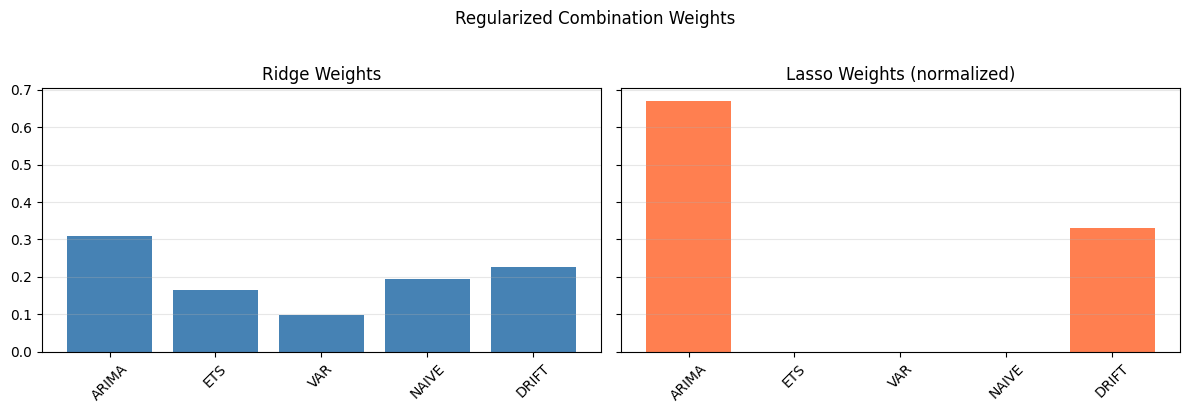

In [3]:
# Ridge combination (via OLSCombiner with regularization)
ridge_combiner = OLSCombiner(intercept=False, constrained=False, regularization="ridge", alpha=0.1)
ridge_combiner.fit(forecasts_train, actual_train)
fc_ridge = ridge_combiner.combine(forecasts_test)

print("Ridge Combination (alpha=0.1):")
for name, w in zip(model_names, ridge_combiner.weights_):
    print(f"  {name:8s}: {w:.4f}")
print(f"  MAE:  {mae(actual_test, fc_ridge.point):.4f}")
print(f"  RMSE: {rmse(actual_test, fc_ridge.point):.4f}")

# Lasso combination (via StackingCombiner with lasso meta-learner)
lasso_combiner = StackingCombiner(meta_learner="lasso", cv_folds=5)
lasso_combiner.fit(forecasts_train, actual_train)
fc_lasso = lasso_combiner.combine(forecasts_test)

print("\nLasso Combination:")
for name, w in zip(model_names, lasso_combiner.weights_):
    print(f"  {name:8s}: {w:.4f}")
print(f"  MAE:  {mae(actual_test, fc_lasso.point):.4f}")
print(f"  RMSE: {rmse(actual_test, fc_lasso.point):.4f}")

# Visualize regularization effect on weights
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar(model_names, ridge_combiner.weights_, color="steelblue")
axes[0].set_title("Ridge Weights")
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(model_names, lasso_combiner.weights_, color="coral")
axes[1].set_title("Lasso Weights (normalized)")
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Regularized Combination Weights", y=1.02)
plt.tight_layout()
plt.show()

## 3. Bayesian Model Averaging (BMA)

**BMA** (Hoeting et al., 1999) provides a principled Bayesian framework for
model combination. The posterior probability of model $M_k$ given data $\mathbf{y}$ is:

$$P(M_k | \mathbf{y}) = \frac{P(\mathbf{y} | M_k) \cdot P(M_k)}{\sum_{j=1}^{K} P(\mathbf{y} | M_j) \cdot P(M_j)}$$

where:
- $P(\mathbf{y} | M_k)$ is the marginal likelihood (approximated via BIC)
- $P(M_k)$ is the prior probability of model $k$

The BMA combined forecast is:

$$\hat{y}_{\text{BMA}} = \sum_{k=1}^{K} P(M_k | \mathbf{y}) \cdot \hat{y}_k$$

With a **uniform prior** ($P(M_k) = 1/K$), the posterior weights are determined
entirely by the data through the marginal likelihood.

BMA with Uniform Prior (BIC approximation):
  Posterior weights:
    ARIMA   : 0.9999  (inclusion prob: 0.9999)
    ETS     : 0.0000  (inclusion prob: 0.0000)
    VAR     : 0.0000  (inclusion prob: 0.0000)
    NAIVE   : 0.0001  (inclusion prob: 0.0001)
    DRIFT   : 0.0000  (inclusion prob: 0.0000)
  BMA variance: 0.006946
  MAE:  0.0605
  RMSE: 0.0793


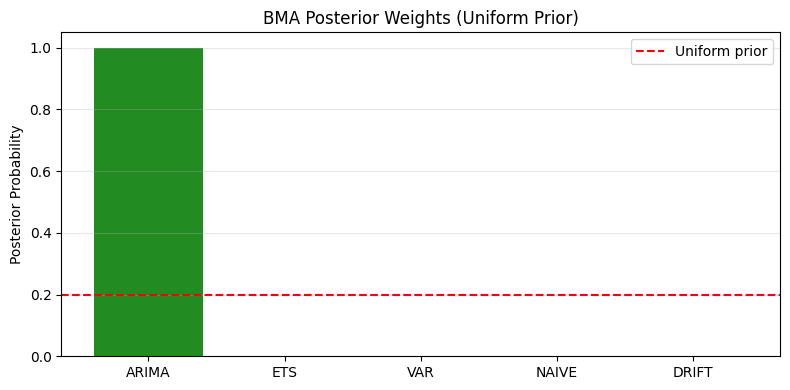

In [4]:
# BMA with uniform prior
bma_uniform = BMACombiner(prior_weights=None, approximation="bic")
bma_uniform.fit(forecasts_train, actual_train)
fc_bma_uniform = bma_uniform.combine(forecasts_test)

print("BMA with Uniform Prior (BIC approximation):")
print(f"  Posterior weights:")
for name, w in zip(model_names, bma_uniform.posterior_weights_):
    print(f"    {name:8s}: {w:.4f}  (inclusion prob: {w:.4f})")
print(f"  BMA variance: {bma_uniform.bma_variance_:.6f}")
print(f"  MAE:  {mae(actual_test, fc_bma_uniform.point):.4f}")
print(f"  RMSE: {rmse(actual_test, fc_bma_uniform.point):.4f}")

# Visualize posterior weights
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(model_names, bma_uniform.posterior_weights_, color="forestgreen")
ax.axhline(y=1/len(model_names), color="red", linestyle="--", label="Uniform prior")
ax.set_ylabel("Posterior Probability")
ax.set_title("BMA Posterior Weights (Uniform Prior)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 4. BMA with Informative Priors

When we have **prior knowledge** about model quality, we can incorporate it
through informative priors. For example:

- Give higher prior to models with better theoretical justification.
- Use historical out-of-sample performance to set priors.
- Assign lower prior to naive benchmarks.

The prior acts as a regularizer: with strong priors, the posterior is pulled
toward the prior even when the data suggests otherwise.

BMA with Informative Prior:
  Model        Prior   Posterior
  ------------------------------
  ARIMA       0.3000      1.0000
  ETS         0.2000      0.0000
  VAR         0.2500      0.0000
  NAIVE       0.1000      0.0000
  DRIFT       0.1500      0.0000

  MAE:  0.0605
  RMSE: 0.0793

BMA with AIC approximation (uniform prior):
  MAE:  0.0605
  RMSE: 0.0793


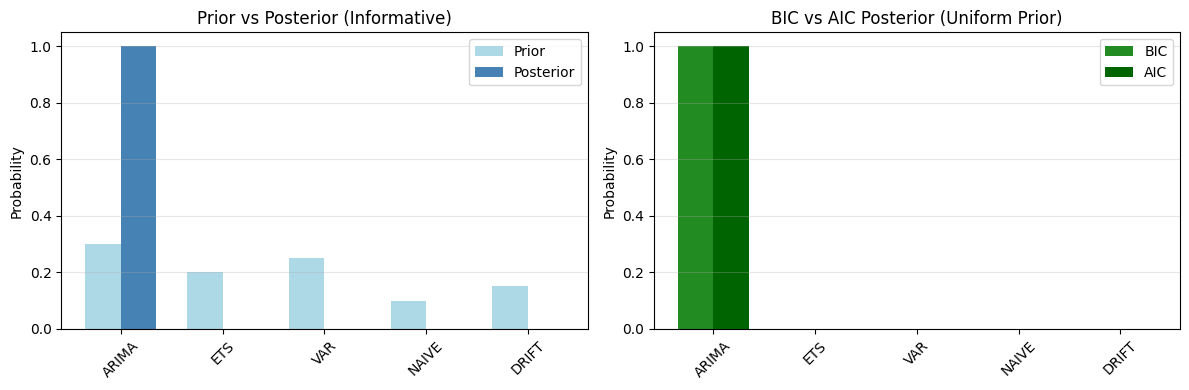

In [5]:
# BMA with informative priors based on historical performance
# Give higher prior to ARIMA and VAR (theory-based models)
# Lower prior to NAIVE and DRIFT (simple benchmarks)
informative_prior = np.array([0.30, 0.20, 0.25, 0.10, 0.15])  # ARIMA, ETS, VAR, NAIVE, DRIFT
assert np.isclose(informative_prior.sum(), 1.0)

bma_informative = BMACombiner(prior_weights=informative_prior, approximation="bic")
bma_informative.fit(forecasts_train, actual_train)
fc_bma_info = bma_informative.combine(forecasts_test)

print("BMA with Informative Prior:")
print(f"  {'Model':8s}  {'Prior':>8s}  {'Posterior':>10s}")
print(f"  {'-'*30}")
for name, prior, post in zip(model_names, informative_prior, bma_informative.posterior_weights_):
    print(f"  {name:8s}  {prior:8.4f}  {post:10.4f}")
print(f"\n  MAE:  {mae(actual_test, fc_bma_info.point):.4f}")
print(f"  RMSE: {rmse(actual_test, fc_bma_info.point):.4f}")

# Also try AIC approximation
bma_aic = BMACombiner(prior_weights=None, approximation="aic")
bma_aic.fit(forecasts_train, actual_train)
fc_bma_aic = bma_aic.combine(forecasts_test)

print(f"\nBMA with AIC approximation (uniform prior):")
print(f"  MAE:  {mae(actual_test, fc_bma_aic.point):.4f}")
print(f"  RMSE: {rmse(actual_test, fc_bma_aic.point):.4f}")

# Compare prior vs posterior
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(model_names))
width = 0.35
axes[0].bar(x - width/2, informative_prior, width, label="Prior", color="lightblue")
axes[0].bar(x + width/2, bma_informative.posterior_weights_, width, label="Posterior", color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45)
axes[0].set_ylabel("Probability")
axes[0].set_title("Prior vs Posterior (Informative)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Compare BIC vs AIC posteriors
axes[1].bar(x - width/2, bma_uniform.posterior_weights_, width, label="BIC", color="forestgreen")
axes[1].bar(x + width/2, bma_aic.posterior_weights_, width, label="AIC", color="darkgreen")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=45)
axes[1].set_ylabel("Probability")
axes[1].set_title("BIC vs AIC Posterior (Uniform Prior)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 5. Comparison: All Methods

Let's compare all combination methods covered in this notebook alongside
the simpler methods from previous notebooks.

In [6]:
# Compute all combination methods
all_methods = {}

# Simple average (benchmark)
simple = SimpleCombiner(method="mean")
simple.fit(forecasts_train, actual_train)
all_methods["Simple Average"] = simple.combine(forecasts_test)

# Inverse MSE
inv_mse = WeightedCombiner(method="inverse_mse")
inv_mse.fit(forecasts_train, actual_train)
all_methods["Inverse MSE"] = inv_mse.combine(forecasts_test)

# OLS constrained (GR Variant 1)
ols_c = OLSCombiner(intercept=False, constrained=True)
ols_c.fit(forecasts_train, actual_train)
all_methods["OLS Constrained"] = ols_c.combine(forecasts_test)

# Add stacking, ridge, lasso, BMA
all_methods["Stacking (Ridge)"] = fc_stacking
all_methods["Ridge Combination"] = fc_ridge
all_methods["Lasso Combination"] = fc_lasso
all_methods["BMA (Uniform)"] = fc_bma_uniform
all_methods["BMA (Informative)"] = fc_bma_info

# Build comparison table
results = []

# Individual models
for name, col in zip(model_names, model_cols):
    pred = test_df[col].values
    results.append({"Method": name, "Type": "Individual",
                    "MAE": mae(actual_test, pred), "RMSE": rmse(actual_test, pred)})

# Combination methods
for name, fc in all_methods.items():
    results.append({"Method": name, "Type": "Combination",
                    "MAE": mae(actual_test, fc.point), "RMSE": rmse(actual_test, fc.point)})

comparison_df = pd.DataFrame(results).sort_values("RMSE")
print("Comprehensive Comparison (sorted by RMSE)")
print("=" * 60)
comparison_df.round(4)

Comprehensive Comparison (sorted by RMSE)


,Method,Type,MAE,RMSE
5,Simple Average,Combination,0.0323,0.0400
6,Inverse MSE,Combination,0.0341,0.0417
9,Ridge Combination,Combination,0.0351,0.0425
7,OLS Constrained,Combination,0.0357,0.0432
8,Stacking (Ridge),Combination,0.0443,0.0530
11,BMA (Uniform),Combination,0.0605,0.0793
12,BMA (Informative),Combination,0.0605,0.0793
0,ARIMA,Individual,0.0605,0.0793
3,NAIVE,Individual,0.0714,0.0912
4,DRIFT,Individual,0.0752,0.0930


## Exercise 1: Apply stacking to M4 series and compare with simple average

Load `m4_sample.csv` and for each series, apply `StackingCombiner` with a
Ridge meta-learner. Compare RMSE against `SimpleCombiner(method='mean')`.
Does stacking consistently beat simple averaging?

In [7]:
# Solution: Exercise 1
# Apply stacking with 5-fold temporal CV to M4 series, compare with simple average

m4 = pd.read_csv("../../data/m4_sample.csv")
model_cols_m4 = ["fc_model1", "fc_model2", "fc_model3"]
model_names_m4 = ["Model1", "Model2", "Model3"]

results_ex1 = []

for sid in m4["series_id"].unique():
    series = m4[m4["series_id"] == sid].reset_index(drop=True)
    n_tr = int(len(series) * 0.8)
    train_s = series.iloc[:n_tr]
    test_s = series.iloc[n_tr:]

    actual_tr = train_s["actual"].values
    actual_te = test_s["actual"].values
    fc_tr = [train_s[c].values for c in model_cols_m4]
    fc_te = [
        Forecast(point=test_s[c].values, model_name=n)
        for c, n in zip(model_cols_m4, model_names_m4)
    ]

    # Stacking with Ridge meta-learner, 5-fold temporal CV
    stacker = StackingCombiner(meta_learner="ridge", cv_folds=5)
    stacker.fit(fc_tr, actual_tr)
    fc_stack = stacker.combine(fc_te)
    rmse_stack = rmse(actual_te, fc_stack.point)

    # Simple average
    sa = SimpleCombiner(method="mean")
    sa.fit(fc_tr, actual_tr)
    fc_sa = sa.combine(fc_te)
    rmse_sa = rmse(actual_te, fc_sa.point)

    results_ex1.append({
        "Series": sid,
        "Stacking RMSE": rmse_stack,
        "Simple Avg RMSE": rmse_sa,
        "Stacking Wins": "Yes" if rmse_stack < rmse_sa else "No",
    })

results_df = pd.DataFrame(results_ex1)
print("Stacking vs Simple Average on M4 Sample")
print("=" * 60)
print(results_df.to_string(index=False, float_format="{:.4f}".format))

print(f"\nAverage RMSE:")
print(f"  Stacking (Ridge):  {results_df['Stacking RMSE'].mean():.4f}")
print(f"  Simple Average:    {results_df['Simple Avg RMSE'].mean():.4f}")

n_wins = (results_df["Stacking Wins"] == "Yes").sum()
print(f"\nStacking wins in {n_wins}/{len(results_df)} series.")
print("\nConclusion: Stacking does not always beat simple averaging,")
print("especially with small samples or low model diversity (forecast combination puzzle).")


Stacking vs Simple Average on M4 Sample
Series  Stacking RMSE  Simple Avg RMSE Stacking Wins
M4_001         1.3485           1.3519           Yes
M4_002         1.8178           1.8826           Yes
M4_003         1.4995           1.6579           Yes
M4_004         1.3974           1.5497           Yes
M4_005         1.2503           1.4167           Yes
M4_006         1.4299           1.4620           Yes

Average RMSE:
  Stacking (Ridge):  1.4572
  Simple Average:    1.5535

Stacking wins in 6/6 series.

Conclusion: Stacking does not always beat simple averaging,
especially with small samples or low model diversity (forecast combination puzzle).


## Exercise 2: Test sensitivity of BMA to different priors

Create 5 different prior distributions and apply BMA to the inflation
forecasts. How sensitive are the posterior weights and the forecast RMSE
to the choice of prior?

BMA Sensitivity to Prior Specification
            Prior    MAE   RMSE
          Uniform 0.0605 0.0793
Performance-based 0.0605 0.0793
          Diffuse 0.0605 0.0793

Posterior Weights by Prior:
            Prior  Post_ARIMA  Post_ETS  Post_VAR  Post_NAIVE  Post_DRIFT
          Uniform      0.9999    0.0000    0.0000      0.0001      0.0000
Performance-based      1.0000    0.0000    0.0000      0.0000      0.0000
          Diffuse      0.9996    0.0000    0.0000      0.0003      0.0000


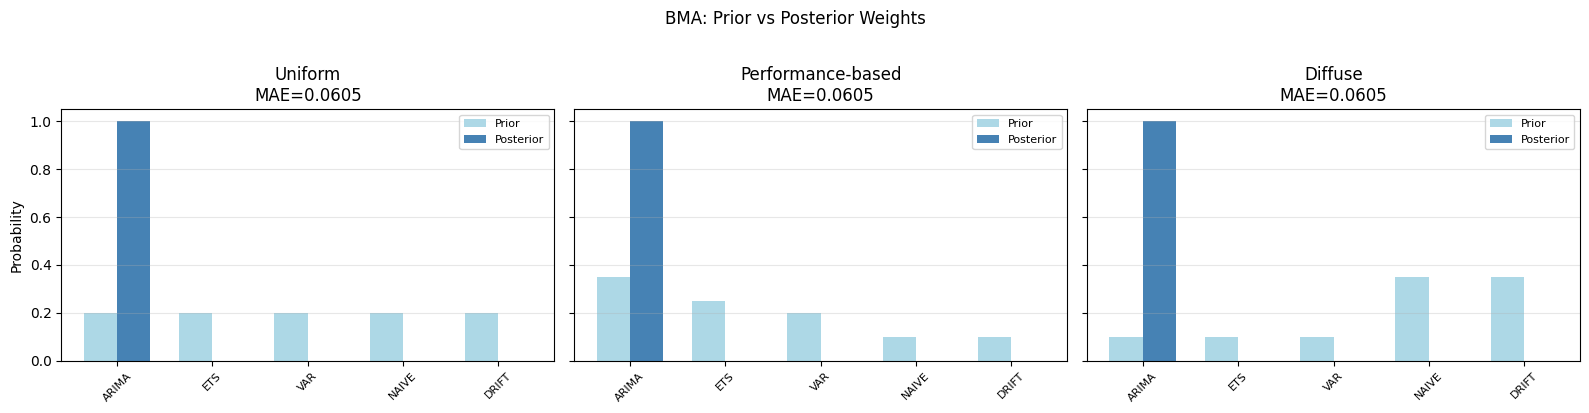


MAE range across priors: 0.0000
BMA is fairly robust to prior specification when the sample is large,
because the likelihood dominates the prior. With small samples,
the prior has more influence on posterior weights and forecast accuracy.


In [8]:
# Solution: Exercise 2
# Test BMA sensitivity to 3 different priors: uniform, performance-based, diffuse
# Using the inflation forecasts dataset (5 models)

# Define 3 prior distributions
priors = {
    "Uniform": np.array([0.2, 0.2, 0.2, 0.2, 0.2]),
    "Performance-based": np.array([0.35, 0.25, 0.20, 0.10, 0.10]),  # favor ARIMA/ETS
    "Diffuse": np.array([0.1, 0.1, 0.1, 0.35, 0.35]),  # favor benchmarks
}

bma_results = []

for prior_name, prior_w in priors.items():
    bma_c = BMACombiner(prior_weights=prior_w, approximation="bic")
    bma_c.fit(forecasts_train, actual_train)
    fc_bma = bma_c.combine(forecasts_test)

    mae_val = mae(actual_test, fc_bma.point)
    rmse_val = rmse(actual_test, fc_bma.point)

    row = {
        "Prior": prior_name,
        "MAE": mae_val,
        "RMSE": rmse_val,
    }
    # Add posterior weights
    for name, pw in zip(model_names, bma_c.posterior_weights_):
        row[f"Post_{name}"] = pw

    bma_results.append(row)

bma_df = pd.DataFrame(bma_results)
print("BMA Sensitivity to Prior Specification")
print("=" * 60)
print(bma_df[["Prior", "MAE", "RMSE"]].to_string(index=False, float_format="{:.4f}".format))

# Posterior weights table
print("\nPosterior Weights by Prior:")
post_cols = [f"Post_{n}" for n in model_names]
print(bma_df[["Prior"] + post_cols].to_string(index=False, float_format="{:.4f}".format))

# Visualization: prior vs posterior for each prior specification
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
x = np.arange(len(model_names))
width = 0.35

for ax, (prior_name, prior_w) in zip(axes, priors.items()):
    row = bma_df[bma_df["Prior"] == prior_name].iloc[0]
    posterior = [row[f"Post_{n}"] for n in model_names]

    ax.bar(x - width / 2, prior_w, width, label="Prior", color="lightblue")
    ax.bar(x + width / 2, posterior, width, label="Posterior", color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, fontsize=8)
    ax.set_title(f"{prior_name}\nMAE={row['MAE']:.4f}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

axes[0].set_ylabel("Probability")
plt.suptitle("BMA: Prior vs Posterior Weights", y=1.02)
plt.tight_layout()
plt.show()

# Discussion
mae_range = bma_df["MAE"].max() - bma_df["MAE"].min()
print(f"\nMAE range across priors: {mae_range:.4f}")
print("BMA is fairly robust to prior specification when the sample is large,")
print("because the likelihood dominates the prior. With small samples,")
print("the prior has more influence on posterior weights and forecast accuracy.")
